### Set script-level configuration and parameters

In [ ]:
from pathlib import Path
from dataclasses import dataclass
from tqdm import trange
import yaml
import pickle
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import trange

from RandAR.utils import instantiate_from_config
from RandAR.dataset.nlcd_dataset import NLCDDataset, detokenize
from RandAR.utils.inpainting import generate_inpainting


@dataclass
class Cfg:
    top_path: Path = Path.cwd().parent
    config_path: Path = top_path / 'configs/randar_nlcd_128_large.yaml'
    checkpoint_path: Path = top_path / 'results/randar_nlcd_128_large/checkpoints/iter_180000'
    data_path: Path = top_path / 'data/data_128_final.npz'
    viz_dir: Path = top_path / 'results' / 'visualizations'
    device: str = 'cuda' if torch.cuda.is_available() else 'cpu'
    n_samples: int = 8
    temperature: float = 1.0
    top_k: int = 0
    top_p: float = 1.0
    # Tokenization downsample factor D, and token grid size
    token_H: int = 64
    token_W: int = 64
    D: int = 2  # raw pixels per token along one axis
    # City of interest
    city_lon: float = -96.7793  # Fargo, ND approx lon
    city_lat: float = 33.3259   # Fargo, ND approx lat
    # Mask threshold in raw pixels from center
    raw_radius: int = 30
    load_samples_from_file: bool = True
    samples_path: Path = top_path / 'data' / 'case_study_samples.pkl'

cfg = Cfg()


### Load model and training data

In [106]:

# Load model
with open(cfg.config_path, 'r') as f:
    config_dict = yaml.safe_load(f)
model = instantiate_from_config(config_dict['ar_model'])
model = model.to(cfg.device).eval()

# Load weights
from safetensors.torch import load_file
model_file = cfg.checkpoint_path / 'model.safetensors'
_ = model.load_state_dict(load_file(model_file))

# Load decode table and tokenized arrays
npz = np.load(cfg.data_path)
decode_table = npz['decode_table']
train_tokens = npz['train_data_tokenized']
train_coords = npz.get('train_coords')

print('Loaded:', train_tokens.shape, 'decode_table:', decode_table.shape)


Loaded: (513024, 64, 64) decode_table: (49928, 2, 2)


### Find nearest imagery

Nearest index: 305099 distance: 0.020001716207655906


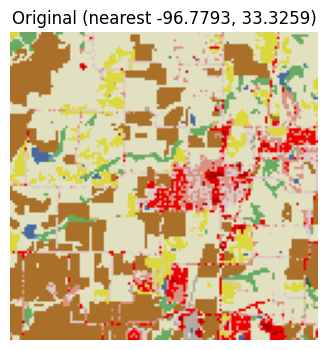

In [107]:


# Select sample nearest to Fargo
assert train_coords is not None, 'Coordinates not found in dataset npz'
lonlat = train_coords  # shape (N, 2)

diffs = lonlat - np.array([cfg.city_lon, cfg.city_lat])[None, :]
dists = np.linalg.norm(diffs, axis=1)
idx = int(np.argmin(dists))
print('Nearest index:', idx, 'distance:', dists[idx])


# elevation map for this data is in the second channel of the training data
elevation = npz['train_data'][idx, 1, :, :]

# Token grid and detokenized raw for visualization
tokens_hw = train_tokens[idx]  # (H_t, W_t)
raw = detokenize(tokens_hw, decode_table)  # (H_r, W_r) with NLCD codes

plt.figure(figsize=(4,4))
rgb = np.zeros((raw.shape[0], raw.shape[1], 3), dtype=np.float32)
for cls, rgbv in NLCDDataset.NLCD_TO_RGB.items():
    rgb[raw == cls] = rgbv
plt.imshow(rgb)
plt.axis('off')
plt.title(f'Original (nearest {cfg.city_lon}, {cfg.city_lat})')
plt.show()


### Visualize elevation + land cover

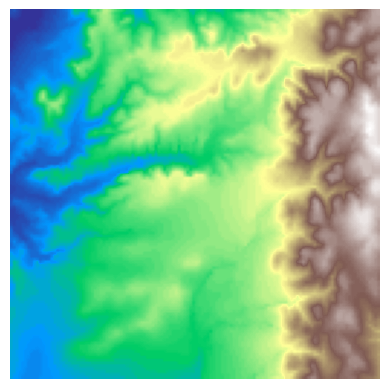

In [108]:
plt.imshow(elevation, cmap='terrain')
plt.axis('off')
plt.show()

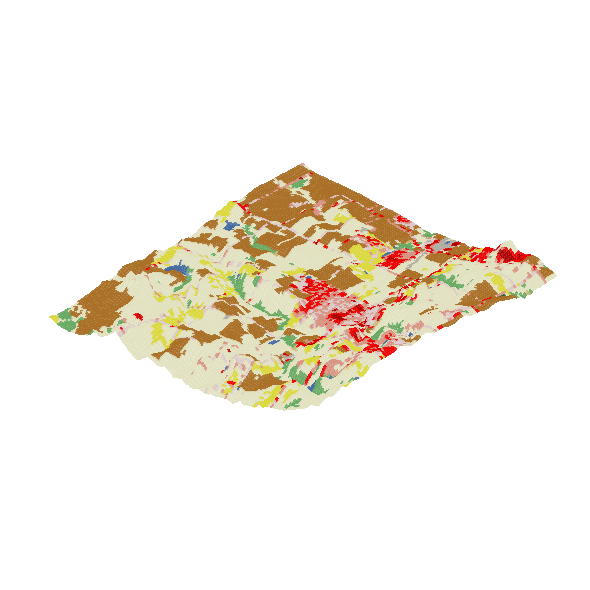

In [109]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
H, W = elevation.shape
lc_rgb = np.zeros((H, W, 3), dtype=np.float32)
for cls, rgbv in NLCDDataset.NLCD_TO_RGB.items():
    lc_rgb[raw == cls] = rgbv
facecolors = np.dstack((lc_rgb, np.full((H, W, 1), 0.85, dtype=np.float32)))
X, Y = np.meshgrid(np.arange(W), np.arange(H))
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, elevation, rstride=1, cstride=1, facecolors=facecolors, linewidth=0, antialiased=False, shade=False)
ax.set_axis_off()
ax.set_box_aspect((1, 1, 0.2))
ax.set_proj_type('ortho')
ax.view_init(elev=35, azim=-45)
fig.patch.set_alpha(0.0)
ax.set_facecolor((0, 0, 0, 0))
try:
    ax.xaxis.pane.set_alpha(0.0)
    ax.yaxis.pane.set_alpha(0.0)
    ax.zaxis.pane.set_alpha(0.0)
except Exception:
    pass
out_path = cfg.top_path / 'results' / 'visualizations' / 'case_study_isomorphic.png'
out_path.parent.mkdir(parents=True, exist_ok=True)
plt.tight_layout()
fig.savefig(out_path, dpi=300, bbox_inches='tight', pad_inches=0, transparent=True)
plt.show()


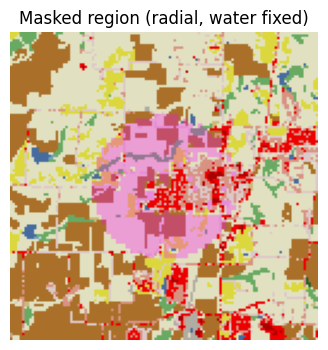

Known: 3596 Unknown: 500


In [110]:

# Water classes should not be placed or sampled by the model and should
# also not be removed in the mask

classes_no_mask = [11, 12, 90, 95, 22, 23, 24, 25]
classes_no_place = [11, 12, 90, 95]

# Create logit mask: for any tokens whose pixels contain one of the forbidden classes,
# set the logit to -inf
flat_tokens = decode_table.reshape(-1, cfg.D, cfg.D)

# Build radial mask: mask tokens whose raw-pixel centers are > cfg.raw_radius from raw center
H_r, W_r = raw.shape
cy, cx = H_r // 2, W_r // 2

# Compute token centers in raw space
H_t, W_t = tokens_hw.shape
yt, xt = np.meshgrid(np.arange(H_t), np.arange(W_t), indexing='ij')
# token center in raw pixel coordinates
yc = yt * cfg.D + (cfg.D - 1) / 2.0
xc = xt * cfg.D + (cfg.D - 1) / 2.0

r = np.sqrt((yc - cy)**2 + (xc - cx)**2)
radial_mask = (r < cfg.raw_radius)

# Keep any token that includes water unmasked
kept_classes = np.array(classes_no_mask, dtype=raw.dtype)
has_kept_token  = np.zeros((H_t, W_t), dtype=bool)
for iy in range(H_t):
    ys = iy * cfg.D
    for ix in range(W_t):
        xs = ix * cfg.D
        if np.any(np.isin(raw[ys:ys+cfg.D, xs:xs+cfg.D], kept_classes)):
            has_kept_token[iy, ix] = True

mask_tokens = radial_mask & (~has_kept_token)

# Visualize mask on raw image
overlay = rgb.copy()
overlay_mask = np.zeros((H_r, W_r), dtype=np.float32)
for iy in range(H_t):
    for ix in range(W_t):
        if mask_tokens[iy, ix]:
            ys = iy*cfg.D
            xs = ix*cfg.D
            overlay[ys:ys+cfg.D, xs:xs+cfg.D, :] = [1.0, 0.0, 1.0]
            overlay_mask[ys:ys+cfg.D, xs:xs+cfg.D] = 1.0

plt.figure(figsize=(4,4))
plt.imshow(0.7*rgb + 0.3*overlay)
plt.axis('off')
plt.title('Masked region (radial, water fixed)')
plt.show()

# Flatten known/unknown positions for inpainting API
known_positions = []
known_tokens = []
unknown_positions = []
flat_tokens = tokens_hw.flatten()
for pos in range(H_t*W_t):
    iy, ix = divmod(pos, W_t)
    if mask_tokens[iy, ix]:
        unknown_positions.append(pos)
    else:
        known_positions.append(pos)
        known_tokens.append(int(flat_tokens[pos]))

known_positions = torch.tensor(known_positions, dtype=torch.long, device=cfg.device)
known_tokens = torch.tensor(known_tokens, dtype=torch.long, device=cfg.device)
unknown_positions = torch.tensor(unknown_positions, dtype=torch.long, device=cfg.device)
print('Known:', len(known_positions), 'Unknown:', len(unknown_positions))


### Run conditional sampling

In [111]:
if cfg.load_samples_from_file:
    with open(cfg.samples_path , 'rb') as f:
        samples_bias = pickle.load(f)
else:

    # Resample using logit_bias to suppress water tokens
    # Build a logit bias over the vocab: set water-token logits to -inf (large negative)
    classes_no_place = np.array(classes_no_place, dtype=np.int64)
    flat_decode = decode_table.reshape(decode_table.shape[0], -1)
    water_token_mask = np.any(np.isin(flat_decode, classes_no_place), axis=1)

    logit_bias = torch.zeros((decode_table.shape[0],), device=cfg.device, dtype=torch.float32)
    logit_bias[torch.from_numpy(water_token_mask).to(cfg.device)] = -1e9

    samples_bias = []
    cond = torch.tensor([0], dtype=torch.long, device=cfg.device)
    for i in range(cfg.n_samples):
        torch.manual_seed(i)
        with torch.no_grad():
            gen_indices = generate_inpainting(
                model=model,
                cond=cond,
                known_tokens=known_tokens,
                known_positions=known_positions,
                unknown_positions=unknown_positions,
                cfg_scales=(1.0, 1.0),
                temperature=cfg.temperature,
                top_k=cfg.top_k,
                top_p=cfg.top_p,
                logit_bias=logit_bias,
            )
        samples_bias.append(gen_indices[0].detach().cpu().numpy().reshape(H_t, W_t))

    len(samples_bias)


    with open(cfg.samples_path, 'wb') as f:
        pickle.dump(samples_bias, f)


100%|██████████| 500/500 [03:02<00:00,  2.75it/s]


### Static visualizations

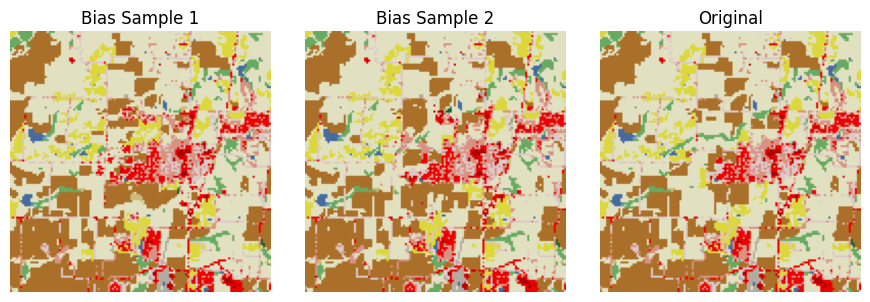

In [112]:
# Quick visualization for logit_bias samples
rows = 1
cols = cfg.n_samples + 1
fig, axes = plt.subplots(rows, cols, figsize=(3*cols, 3*rows))
axes = axes.flatten()

samples_rgb = []

for k, tok_img in enumerate(samples_bias):
    decoded = detokenize(tok_img, decode_table)
    rgb_s = np.zeros((decoded.shape[0], decoded.shape[1], 3), dtype=np.float32)
    for cls, rgbv in NLCDDataset.NLCD_TO_RGB.items():
        rgb_s[decoded == cls] = rgbv
        
    samples_rgb.append(rgb_s)
        

    axes[k].imshow(rgb_s)
    axes[k].set_title(f'Bias Sample {k+1}')
    axes[k].axis('off')
    
# Show original in last column
axes[-1].imshow(rgb)
axes[-1].set_title('Original')
axes[-1].axis('off')

plt.tight_layout()
plt.show()

# First sample is the original
samples_rgb = np.stack([rgb] + samples_rgb, axis=0)

### Animate samples

Total frames to generate: 400
Dynamic pixels per transition: 2000
Pixels updated per frame: 10
Frames per transition: 200
Number of transitions: 2

Rotation parameters:
  Angular velocity: 0.393 rad/s (22.5°/s)
  Rotation per frame: 0.0118 rad (0.67°)
  Animation duration: 12.00 seconds
  Total rotation: 4.71 rad (270.0° = 0.75 rotations)


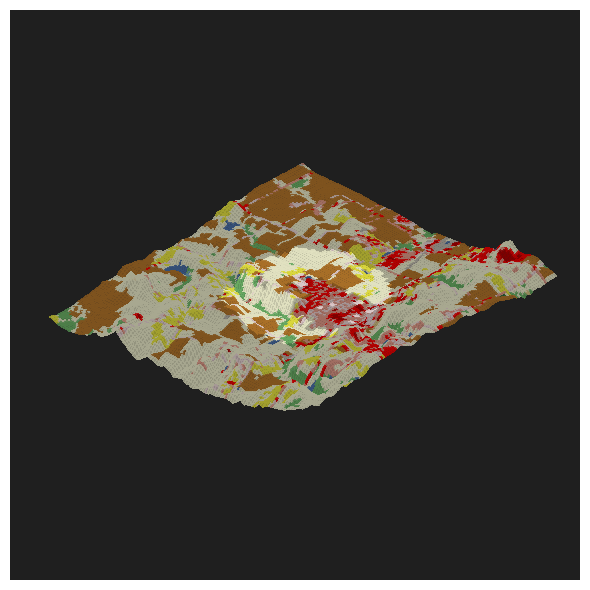

Generating animation frames:   0%|          | 0/400 [00:00<?, ?frame/s]


Starting animation generation...
Converting to HTML5 video...


Sample 1 → 2, Pixels 490/2000, Rotation: 347.4°:  12%|█▎        | 50/400 [01:18<09:42,  1.66s/frame]

CalledProcessError: Command '['ffmpeg', '-f', 'rawvideo', '-vcodec', 'rawvideo', '-s', '600x600', '-pix_fmt', 'rgba', '-framerate', '33.333333333333336', '-loglevel', 'error', '-i', 'pipe:', '-vcodec', 'h264', '-pix_fmt', 'yuv420p', '-y', '/tmp/tmp_4y60z7e/temp.m4v']' returned non-zero exit status 255.

In [ ]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import matplotlib.colors
import numpy as np
from tqdm import tqdm
from dataclasses import dataclass

@dataclass
class AnimationConfig:
    """Configuration parameters for the pixel animation"""
    # Visual styling
    background_color: tuple = None  # Will be set in __post_init__
    shading_factor: float = 0.75  # larger = less dim, smaller = more dim
    surface_alpha: float = 0.85
    
    # Animation parameters
    n_update: int = 10  # Number of pixels to update per frame
    frames_limit: int = None  # Limit frames for testing (set to None for full animation)
    interval: int = 25  # Interval between frames in milliseconds (affects playback speed)
    
    # 3D view parameters
    figure_size: tuple = (6, 6)
    elevation: float = 35
    initial_azimuth: float = -45
    box_aspect: tuple = (1, 1, 0.2)
    projection_type: str = 'ortho'
    
    # Rotation parameters
    angular_velocity: float = np.pi / 8  # Rotation speed in radians per second (π/4 = 45°/sec)
    
    def __post_init__(self):
        if self.background_color is None:
            self.background_color = matplotlib.colors.to_rgba('#141414')
    
    @property
    def angular_velocity_degrees(self):
        """Convert angular velocity to degrees per second for display"""
        return np.degrees(self.angular_velocity)
    
    @property
    def degrees_per_frame(self):
        """Calculate degrees of rotation per frame based on interval"""
        seconds_per_frame = self.interval / 1000.0
        return self.angular_velocity_degrees * seconds_per_frame
    
    @property
    def radians_per_frame(self):
        """Calculate radians of rotation per frame based on interval"""
        seconds_per_frame = self.interval / 1000.0
        return self.angular_velocity * seconds_per_frame

# Create configuration instance
config = AnimationConfig()

# Shade the pixels using the overlay mask from before
frames_arr = samples_rgb.copy()
frames_arr = np.maximum(overlay_mask[..., None], config.shading_factor) * frames_arr
dynamic_pos = np.where(overlay_mask > 0.0)

# Create base figure for update during animation
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

H, W = elevation.shape

# Get the dynamic pixel locations in raster order
dynamic_pixels = list(zip(dynamic_pos[0], dynamic_pos[1]))
dynamic_pixels.sort(key=lambda p: p[0] * W + p[1])  # Sort in raster order

# Calculate total frames needed for pixel-by-pixel transitions
num_samples = len(frames_arr)
pixels_per_transition = len(dynamic_pixels)
# Now we update n_update pixels per frame, so we need fewer frames per transition
frames_per_transition = int(np.ceil(pixels_per_transition / config.n_update))
total_frames = (num_samples - 1) * frames_per_transition

# Calculate animation duration and total rotation
animation_duration = (total_frames * config.interval) / 1000.0  # seconds
total_rotation_rad = config.angular_velocity * animation_duration
total_rotation_deg = np.degrees(total_rotation_rad)
full_rotations = total_rotation_deg / 360.0

print(f"Total frames to generate: {total_frames}")
print(f"Dynamic pixels per transition: {pixels_per_transition}")
print(f"Pixels updated per frame: {config.n_update}")
print(f"Frames per transition: {frames_per_transition}")
print(f"Number of transitions: {num_samples - 1}")
print(f"\nRotation parameters:")
print(f"  Angular velocity: {config.angular_velocity:.3f} rad/s ({config.angular_velocity_degrees:.1f}°/s)")
print(f"  Rotation per frame: {config.radians_per_frame:.4f} rad ({config.degrees_per_frame:.2f}°)")
print(f"  Animation duration: {animation_duration:.2f} seconds")
print(f"  Total rotation: {total_rotation_rad:.2f} rad ({total_rotation_deg:.1f}° = {full_rotations:.2f} rotations)")

# Initialize with the first sample
current_colors = frames_arr[0].copy()
facecolors = np.dstack((current_colors, np.full((H, W, 1), config.surface_alpha, dtype=np.float32)))

X, Y = np.meshgrid(np.arange(W), np.arange(H))

fig = plt.figure(figsize=config.figure_size, frameon=False)
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, elevation, rstride=1, cstride=1, facecolors=facecolors, 
                       linewidth=0, antialiased=False, shade=False)
ax.set_axis_off()
ax.set_box_aspect(config.box_aspect)
ax.set_proj_type(config.projection_type)
ax.view_init(elev=config.elevation, azim=config.initial_azimuth)
fig.patch.set_alpha(0.0)
ax.set_facecolor(config.background_color)
try:
    ax.xaxis.pane.set_alpha(0.0)
    ax.yaxis.pane.set_alpha(0.0)
    ax.zaxis.pane.set_alpha(0.0)
except Exception:
    pass

plt.tight_layout()
plt.show()

# Create progress bar
pbar = tqdm(total=total_frames, desc="Generating animation frames", unit="frame")

def update(frame):
    global current_colors
    
    # Update progress bar
    pbar.update(1)
    
    # Determine which transition we're in and which pixel group to update
    transition_idx = frame // frames_per_transition
    frame_in_transition = frame % frames_per_transition
    
    # Get source and target samples
    source_idx = transition_idx
    target_idx = transition_idx + 1
    
    # Only update if we have a valid target
    if target_idx < num_samples:
        # Calculate which pixels to update in this frame
        start_pixel_idx = frame_in_transition * config.n_update
        end_pixel_idx = min(start_pixel_idx + config.n_update, pixels_per_transition)
        
        # Update multiple pixels in this frame
        for pixel_idx in range(start_pixel_idx, end_pixel_idx):
            # Get the pixel coordinates
            y, x = dynamic_pixels[pixel_idx]
            
            # Update the pixel from source to target color
            current_colors[y, x] = frames_arr[target_idx][y, x]
    
    # Clear the current surface and redraw with updated colors
    ax.clear()
    facecolors = np.dstack((current_colors, np.full((H, W, 1), config.surface_alpha, dtype=np.float32)))
    ax.plot_surface(X, Y, elevation, rstride=1, cstride=1, facecolors=facecolors, 
                    linewidth=0, antialiased=False, shade=False)
    
    # Calculate current rotation angle based on angular velocity
    current_azim = config.initial_azimuth + (frame * config.degrees_per_frame)
    
    # Restore view settings with updated azimuth angle
    ax.set_axis_off()
    ax.set_box_aspect(config.box_aspect)
    ax.set_proj_type(config.projection_type)
    ax.view_init(elev=config.elevation, azim=current_azim)
    ax.set_facecolor(config.background_color)
    try:
        ax.xaxis.pane.set_alpha(0.0)
        ax.yaxis.pane.set_alpha(0.0)
        ax.zaxis.pane.set_alpha(0.0)
    except Exception:
        pass
    
    # Update progress bar description with current status
    if frame == total_frames - 1:
        pbar.set_description("Animation complete!")
    else:
        transition_name = f"Sample {source_idx+1} → {target_idx+1}"
        pixels_updated = min((frame_in_transition + 1) * config.n_update, pixels_per_transition)
        pixel_progress = f"Pixels {pixels_updated}/{pixels_per_transition}"
        rotation_info = f"Rotation: {current_azim % 360:.1f}°"
        pbar.set_description(f"{transition_name}, {pixel_progress}, {rotation_info}")
    
    return ax,

print(f"\nStarting animation generation...")

# Use frames_limit if set, otherwise use total_frames
animation_frames = min(config.frames_limit, total_frames) if config.frames_limit else total_frames

anim = FuncAnimation(
    fig, 
    update, 
    frames=animation_frames,
    interval=config.interval,
    blit=False)

# Generate the video (this is where the actual frame generation happens)
print("Converting to HTML5 video...")
html_video = anim.to_html5_video()

# Close the progress bar
pbar.close()

print("Animation generation complete!")

# Display the video
HTML(html_video)


In [ ]:
anim.save(cfg.viz_dir / 'lc-transition.mp4', writer='ffmpeg', fps=45, dpi=300)

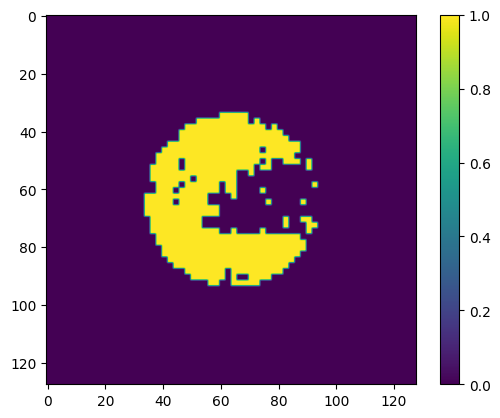

In [115]:
plt.imshow(overlay_mask)
plt.colorbar()